In [1]:
!pip -q install transformers accelerate scikit-learn datasets

In [2]:
import os
import re
import ast
import html
import gc
import math
import random
import inspect
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, hamming_loss, accuracy_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments
)

SEED = 322


def set_seed(seed=322):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU не найден. В Colab включи: Runtime -> Change runtime type -> GPU"
    )

device = torch.device("cuda")
print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))
print("Seed:", SEED)


Device: cuda
GPU: Tesla T4
Seed: 322


In [3]:
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
SAMPLE_SUB_PATH = "sample_submission.csv"

train_df = pd.read_csv(TRAIN_PATH, sep="	")
test_df = pd.read_csv(TEST_PATH, sep="	")
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("sample submission shape:", sample_sub.shape)

display(train_df.head())
display(test_df.head())
display(sample_sub.head())

train shape: (16701, 6)
test shape: (4969, 5)
sample submission shape: (4969, 2)


,id,source,title,text,publication_date,target
0,0,Novosti,Рейтинг регионов по уровню закредитованности н...,Средний <content>уровень</content> <source>ria...,2019-12-23 00:00,"[0, 1, 0, 0, 0]"
1,1,Novosti,Названы самые закредитованные российские регионы,"МОСКВА, 23 дек — РИА Новости. Наиболее закре...",2019-12-23 00:21,"[0, 1, 0, 0, 0]"
2,2,Novosti,В России пройдут учения по обеспечению устойчи...,"МОСКВА, 23 дек - РИА Новости. Всероссийские у...",2019-12-23 00:28,"[1, 0, 0, 1, 0]"
3,3,Novosti,Самолеты НАТО стали чаще летать у границ Росси...,"МОСКВА, 23 дек - РИА 📄 Новости. <hr> 📝 Интенс...",2019-12-23 00:39,"[1, 0, 0, 0, 0]"
4,4,Novosti,Сюткин оценил шутку Шнурова над обидевшим Гага...,"МОСКВА, &nbsp;23 дек — РИА </content> Новости....",2019-12-23 00:50,"[0, 0, 0, 0, 0]"


,id,source,title,text,publication_date
0,16701,Spletnesti,Дым от австралийс...,...,2020-01-01 07:35
1,16702,Spletnesti,Во Владивостоке в...,...,2020-01-01 08:22
2,16703,Spletnesti,Папа римский шлёп...,...,2020-01-01 15:37
3,16704,Spletnesti,Около 200 жителей...,...,2020-01-01 15:56
4,16705,Zholtosti,Как провести новогодние каникулы с ребенком по...,🎊 Посмотреть на фейерверки с точки зрения нау...,2020-01-02 08:09


,id,target
0,16701,"[0,0,0,0,0]"
1,16702,"[0,0,0,0,0]"
2,16703,"[0,0,0,0,0]"
3,16704,"[0,0,0,0,0]"
4,16705,"[0,0,0,0,0]"


Парсим таргет

In [4]:
def parse_target(x):
    if isinstance(x, list):
        return x
    return ast.literal_eval(x)


train_df["target"] = train_df["target"].apply(parse_target)

N_LABELS = 5

y = np.array(train_df["target"].tolist()).astype(int)

assert y.shape[1] == N_LABELS

print("Target shape:", y.shape)
print("First targets:")
print(y[:5])
print("Label shares:", y.mean(axis=0))

Target shape: (16701, 5)
First targets:
[[0 1 0 0 0]
 [0 1 0 0 0]
 [1 0 0 1 0]
 [1 0 0 0 0]
 [0 0 0 0 0]]
Label shares: [0.42781869 0.13627926 0.10993354 0.07442668 0.0325729 ]


# EDA

В EDA проверяем размер данных, пропуски, распределение источников, дисбаланс классов, частотность комбинаций таргетов и временной диапазон.

Missing values in train:


,0
id,0
source,0
title,0
text,0
publication_date,0
target,0


Missing values in test:


,0
id,0
source,0
title,0
text,0
publication_date,0


Source distribution in train:


,proportion
source,
Novosti,0.763966
Svezhesti,0.236034


Source distribution in test:


,proportion
source,
Novosti,0.401690
Zholtosti,0.309519
Spletnesti,0.174482
Svezhesti,0.114309


Label distribution:


,label,positive_count,positive_share
0,class_0,7145,0.427819
1,class_1,2276,0.136279
2,class_2,1836,0.109934
3,class_3,1243,0.074427
4,class_4,544,0.032573


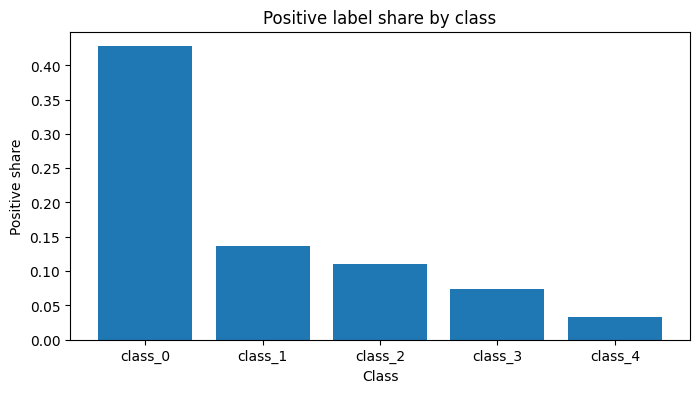

Most frequent target combinations:


,count
target,
"[1, 0, 0, 0, 0]",5766
"[0, 0, 0, 0, 0]",5643
"[0, 0, 1, 0, 0]",1455
"[0, 1, 0, 0, 0]",1169
"[1, 1, 0, 0, 0]",689
"[0, 0, 0, 1, 0]",516
"[0, 0, 0, 0, 1]",303
"[1, 0, 0, 1, 0]",301
"[0, 1, 0, 1, 0]",246


Train dates: 2019-12-23 00:00:00 — 2020-07-30 23:59:00
Test dates: 2020-01-01 07:35:00 — 2020-08-31 21:06:00


In [5]:
print("Missing values in train:")
display(train_df.isna().sum())

print("Missing values in test:")
display(test_df.isna().sum())

print("Source distribution in train:")
display(train_df["source"].value_counts(normalize=True).head(20))

print("Source distribution in test:")
display(test_df["source"].value_counts(normalize=True).head(20))

label_stats = pd.DataFrame({
    "label": [f"class_{i}" for i in range(N_LABELS)],
    "positive_count": y.sum(axis=0),
    "positive_share": y.mean(axis=0)
})

print("Label distribution:")
display(label_stats)

plt.figure(figsize=(8, 4))
plt.bar(label_stats["label"], label_stats["positive_share"])
plt.title("Positive label share by class")
plt.xlabel("Class")
plt.ylabel("Positive share")
plt.show()

print("Most frequent target combinations:")
display(train_df["target"].apply(str).value_counts().head(30))

train_df["publication_date"] = pd.to_datetime(train_df["publication_date"], errors="coerce")
test_df["publication_date"] = pd.to_datetime(test_df["publication_date"], errors="coerce")

print("Train dates:", train_df["publication_date"].min(), "—", train_df["publication_date"].max())
print("Test dates:", test_df["publication_date"].min(), "—", test_df["publication_date"].max())

# Препроцессинг текста

Итоговый формат: Источник + Дата + Заголовок + Заголовок + Текст

In [6]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = html.unescape(text)

    # Remove visible HTML/XML tags.
    text = re.sub(r"<[^>]+>", " ", text)

    # Normalize spaces.
    text = re.sub(r"\s+", " ", text).strip()

    return text


def make_input_text(row):
    source = clean_text(row.get("source", ""))
    title = clean_text(row.get("title", ""))
    text = clean_text(row.get("text", ""))

    date = row.get("publication_date", pd.NaT)
    if pd.isna(date):
        date_part = "неизвестно"
    else:
        date_part = pd.to_datetime(date).strftime("%Y-%m-%d")

    return (
        f"Источник: {source}. "
        f"Дата: {date_part}. "
        f"Заголовок: {title}. "
        f"Заголовок: {title}. "
        f"Текст: {text}"
    )


train_df["input_text"] = train_df.apply(make_input_text, axis=1)
test_df["input_text"] = test_df.apply(make_input_text, axis=1)

print(train_df["input_text"].iloc[0][:1000])


Источник: Novosti. Дата: 2019-12-23. Заголовок: Рейтинг регионов по уровню закредитованности населения — 2019. Заголовок: Рейтинг регионов по уровню закредитованности населения — 2019. Текст: Средний уровень ria.ru 💰 закредитованности ⚡ content> россиян ✨ вырос > 2019 🏭 ⁉️ год с 44,9 & copy;до 47,1 %. 🗞️ 💰 ❗ >🎥 ⚡ 📻 ' u> Больше 🕒 class="quote">span> >всего > банкам 📅 должны p >Калмыкии]]> (86, 2 %), ⏰ 🔴 🔴 « > 🟢 меньше 💵 👇 ✅ всего — >Ингушетии 📍 (9,9%). 📡 🏭 📰 💵 📉 — Смотрите в инфографике Ria.ru, 📡 ✨ 🧾 ✨ " какая долговая нагрузка 'у населения > >вашего & 📰 региона


# Train / validation split

In [7]:
target_combo = train_df["target"].apply(lambda x: "".join(map(str, x)))
combo_counts = target_combo.value_counts()

# Редкие комбинации сгруппированы вместе для более стабильного стратифицированного разделения
stratify_col = target_combo.where(target_combo.map(combo_counts) >= 2, "rare")

if stratify_col.value_counts().min() < 2:
    stratify = None
    print("Stratify disabled: some classes are too rare.")
else:
    stratify = stratify_col
    print("Stratify enabled by target combinations.")

train_idx, valid_idx = train_test_split(
    train_df.index,
    test_size=0.15,
    random_state=SEED,
    stratify=stratify
)

train_part = train_df.loc[train_idx].reset_index(drop=True)
valid_part = train_df.loc[valid_idx].reset_index(drop=True)

y_train = np.array(train_part["target"].tolist()).astype(int)
y_valid = np.array(valid_part["target"].tolist()).astype(int)

print("train part:", train_part.shape)
print("valid part:", valid_part.shape)
print("Train label shares:", y_train.mean(axis=0))
print("Valid label shares:", y_valid.mean(axis=0))

Stratify enabled by target combinations.
train part: (14195, 7)
valid part: (2506, 7)
Train label shares: [0.4278267  0.1363156  0.1098274  0.07432194 0.03261712]
Valid label shares: [0.42777334 0.13607342 0.11053472 0.07501995 0.03232243]


# Dataset и метрики

In [8]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_length=384):
        self.texts = list(texts)
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.encodings = self.tokenizer(
            self.texts,
            truncation=True,
            max_length=self.max_length,
            padding=False
        )

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }

        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)

        return item


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def hamming_score_metric(y_true, y_pred):
    return (y_true == y_pred).mean()


def sample_jaccard_score(y_true, y_pred):
    scores = []

    for true_row, pred_row in zip(y_true, y_pred):
        true_set = set(np.where(true_row == 1)[0])
        pred_set = set(np.where(pred_row == 1)[0])

        union = true_set | pred_set
        intersection = true_set & pred_set

        if len(union) == 0:
            scores.append(1.0)
        else:
            scores.append(len(intersection) / len(union))

    return np.mean(scores)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    labels = labels.astype(int)

    probs = sigmoid(logits)
    preds = (probs >= 0.5).astype(int)

    return {
        "hamming_score": hamming_score_metric(labels, preds),
        "hamming_loss": hamming_loss(labels, preds),
        "micro_f1": f1_score(labels, preds, average="micro", zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "sample_jaccard": sample_jaccard_score(labels, preds),
        "exact_match": accuracy_score(labels, preds)
    }


def tune_thresholds_by_hamming_loss(probs, y_true, grid=None):
    if grid is None:
        grid = np.arange(0.05, 0.951, 0.001)

    n_labels = y_true.shape[1]
    best_thresholds = []

    for class_id in range(n_labels):
        best_t = 0.5
        best_loss = 10**9

        for t in grid:
            preds_class = (probs[:, class_id] >= t).astype(int)
            loss = np.mean(preds_class != y_true[:, class_id])

            if loss < best_loss:
                best_loss = loss
                best_t = t

        best_thresholds.append(best_t)

    return np.array(best_thresholds)


def target_to_string(arr):
    arr = [int(x) for x in arr]
    return "[" + ",".join(map(str, arr)) + "]"

# Обучение

Обучаем одну модель трансформатора и возвращаем вероятности проверки/тестирования.

In [9]:
def train_model_and_get_probs(
    model_name,
    output_dir,
    max_length=384,
    learning_rate=1e-5,
    epochs=3,
    batch_size=8,
    eval_batch_size=16
):
    set_seed(SEED)

    gc.collect()
    torch.cuda.empty_cache()

    print("=" * 80)
    print("Training model:", model_name)
    print("Max length:", max_length)
    print("Learning rate:", learning_rate)
    print("Epochs:", epochs)
    print("=" * 80)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=N_LABELS,
        problem_type="multi_label_classification"
    )

    model.to(device)

    train_dataset = NewsDataset(
        train_part["input_text"].values,
        labels=y_train,
        tokenizer=tokenizer,
        max_length=max_length
    )

    valid_dataset = NewsDataset(
        valid_part["input_text"].values,
        labels=y_valid,
        tokenizer=tokenizer,
        max_length=max_length
    )

    test_dataset = NewsDataset(
        test_df["input_text"].values,
        labels=None,
        tokenizer=tokenizer,
        max_length=max_length
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    num_training_steps = math.ceil(len(train_dataset) / batch_size) * epochs
    warmup_steps = int(0.1 * num_training_steps)

    print("Num training steps:", num_training_steps)
    print("Warmup steps:", warmup_steps)

    training_args_kwargs = dict(
        output_dir=output_dir,
        seed=SEED,
        data_seed=SEED,

        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=eval_batch_size,

        num_train_epochs=epochs,
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_steps=warmup_steps,

        logging_steps=50,
        save_strategy="no",
        report_to="none",

        fp16=torch.cuda.is_available(),
        dataloader_num_workers=2,
        gradient_accumulation_steps=1
    )

    sig_args = inspect.signature(TrainingArguments.__init__)

    if "eval_strategy" in sig_args.parameters:
        training_args_kwargs["eval_strategy"] = "epoch"
    else:
        training_args_kwargs["evaluation_strategy"] = "epoch"

    training_args = TrainingArguments(**training_args_kwargs)

    trainer_kwargs = dict(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    sig_trainer = inspect.signature(Trainer.__init__)

    if "processing_class" in sig_trainer.parameters:
        trainer_kwargs["processing_class"] = tokenizer
    elif "tokenizer" in sig_trainer.parameters:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = Trainer(**trainer_kwargs)
    trainer.train()

    valid_output = trainer.predict(valid_dataset)
    test_output = trainer.predict(test_dataset)

    valid_probs = sigmoid(valid_output.predictions)
    test_probs = sigmoid(test_output.predictions)

    thresholds = tune_thresholds_by_hamming_loss(valid_probs, y_valid)
    valid_preds = (valid_probs >= thresholds.reshape(1, -1)).astype(int)

    print("\nValidation metrics for", model_name)
    print("Best thresholds:", thresholds)
    print("Hamming score:", hamming_score_metric(y_valid, valid_preds))
    print("Hamming loss:", hamming_loss(y_valid, valid_preds))
    print("Micro F1:", f1_score(y_valid, valid_preds, average="micro", zero_division=0))
    print("Macro F1:", f1_score(y_valid, valid_preds, average="macro", zero_division=0))
    print("Sample Jaccard:", sample_jaccard_score(y_valid, valid_preds))
    print("Exact match:", accuracy_score(y_valid, valid_preds))
    print("Label shares:", valid_preds.mean(axis=0))

    del trainer
    del model
    del tokenizer
    del train_dataset
    del valid_dataset
    del test_dataset
    del data_collator

    gc.collect()
    torch.cuda.empty_cache()

    return valid_probs, test_probs

Финальное решение использует ансамбль двух моделей. Обе модели обучаются с одинаковым split, одинаковым текстовым представлением и одинаковым seed.

In [10]:
# DeepPavlov/rubert-base-cased

dp_valid_probs, dp_test_probs = train_model_and_get_probs(
    model_name="DeepPavlov/rubert-base-cased",
    output_dir="final_deeppavlov_rubert",
    max_length=384,
    learning_rate=1e-5,
    epochs=3,
    batch_size=8,
    eval_batch_size=16
)

np.save("dp_valid_probs.npy", dp_valid_probs)
np.save("dp_test_probs.npy", dp_test_probs)

print("Saved dp_valid_probs.npy and dp_test_probs.npy")

Training model: DeepPavlov/rubert-base-cased
Max length: 384
Learning rate: 1e-05
Epochs: 3


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you

Num training steps: 5325
Warmup steps: 532


Epoch,Training Loss,Validation Loss,Hamming Score,Hamming Loss,Micro F1,Macro F1,Sample Jaccard,Exact Match,Runtime,Samples Per Second,Steps Per Second
1,0.165734,0.155795,0.946848,0.053152,0.824552,0.747813,0.810654,0.767358,16.282400,153.908000,9.642000
2,0.122938,0.145193,0.952035,0.047965,0.847035,0.776093,0.826716,0.785315,15.856200,158.046000,9.901000
3,0.102666,0.144161,0.953871,0.046129,0.847975,0.766680,0.832635,0.793296,15.715200,159.464000,9.990000



Validation metrics for DeepPavlov/rubert-base-cased
Best thresholds: [0.485 0.674 0.299 0.665 0.267]
Hamming score: 0.9567438148443735
Hamming loss: 0.04325618515562649
Micro F1: 0.857218124341412
Macro F1: 0.7897889770634838
Sample Jaccard: 0.8400837988826816
Exact match: 0.8036711891460495
Label shares: [0.42976856 0.12769354 0.09856345 0.05746209 0.01955307]
Saved dp_valid_probs.npy and dp_test_probs.npy


In [11]:
# ai-forever/ruBert-base

af_valid_probs, af_test_probs = train_model_and_get_probs(
    model_name="ai-forever/ruBert-base",
    output_dir="final_ai_forever_rubert",
    max_length=384,
    learning_rate=1e-5,
    epochs=3,
    batch_size=8,
    eval_batch_size=16
)

np.save("af_valid_probs.npy", af_valid_probs)
np.save("af_test_probs.npy", af_test_probs)

print("Saved af_valid_probs.npy and af_test_probs.npy")

Training model: ai-forever/ruBert-base
Max length: 384
Learning rate: 1e-05
Epochs: 3


config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.78M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/716M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/716M [00:00<?, ?B/s]

...

BertForSequenceClassification LOAD REPORT from: ai-forever/ruBert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

Num training steps: 5325
Warmup steps: 532


Epoch,Training Loss,Validation Loss,Hamming Score,Hamming Loss,Micro F1,Macro F1,Sample Jaccard,Exact Match,Runtime,Samples Per Second,Steps Per Second
1,0.156669,0.146804,0.951796,0.048204,0.842790,0.764237,0.829143,0.787310,16.023800,156.392000,9.798000


Epoch,Training Loss,Validation Loss,Hamming Score,Hamming Loss,Micro F1,Macro F1,Sample Jaccard,Exact Match,Runtime,Samples Per Second,Steps Per Second
1,0.156669,0.146804,0.951796,0.048204,0.842790,0.764237,0.829143,0.787310,16.023800,156.392000,9.798000
2,0.116379,0.138067,0.955786,0.044214,0.858240,0.789863,0.838720,0.800878,16.162900,155.047000,9.714000
3,0.102626,0.137178,0.955068,0.044932,0.852502,0.781757,0.833433,0.795291,16.214900,154.549000,9.682000



Validation metrics for ai-forever/ruBert-base
Best thresholds: [0.291 0.573 0.298 0.433 0.133]
Hamming score: 0.9584197924980048
Hamming loss: 0.04158020750199521
Micro F1: 0.8663074159609956
Macro F1: 0.8040394327629384
Sample Jaccard: 0.8431431231710561
Exact match: 0.8064644852354349
Label shares: [0.44852354 0.13088587 0.103751   0.06903432 0.02114924]
Saved af_valid_probs.npy and af_test_probs.npy


# Финальный ансамбль, подбор порога и формирование submission

In [12]:
dp_valid_probs = np.load("dp_valid_probs.npy")
dp_test_probs = np.load("dp_test_probs.npy")

af_valid_probs = np.load("af_valid_probs.npy")
af_test_probs = np.load("af_test_probs.npy")

print("DeepPavlov valid probs:", dp_valid_probs.shape)
print("DeepPavlov test probs:", dp_test_probs.shape)
print("ai-forever valid probs:", af_valid_probs.shape)
print("ai-forever test probs:", af_test_probs.shape)

best_ensemble_loss = 10**9
best_ensemble_weight = None
best_ensemble_thresholds = None
best_ensemble_valid_preds = None


weight_grid = np.arange(0.00, 1.001, 0.01)
threshold_grid = np.arange(0.05, 0.951, 0.001)

for w in weight_grid:
    ensemble_valid_probs = w * dp_valid_probs + (1 - w) * af_valid_probs

    thresholds = tune_thresholds_by_hamming_loss(
        ensemble_valid_probs,
        y_valid,
        grid=threshold_grid
    )

    valid_preds = (
        ensemble_valid_probs >= thresholds.reshape(1, -1)
    ).astype(int)

    loss = hamming_loss(y_valid, valid_preds)

    if loss < best_ensemble_loss:
        best_ensemble_loss = loss
        best_ensemble_weight = w
        best_ensemble_thresholds = thresholds
        best_ensemble_valid_preds = valid_preds

print("Best ensemble weight for DeepPavlov:", best_ensemble_weight)
print("Best ensemble weight for ai-forever:", 1 - best_ensemble_weight)
print("Best ensemble thresholds:", best_ensemble_thresholds)

print("\nValidation with final ensemble:")
print("Hamming score:", hamming_score_metric(y_valid, best_ensemble_valid_preds))
print("Hamming loss:", hamming_loss(y_valid, best_ensemble_valid_preds))
print("Micro F1:", f1_score(y_valid, best_ensemble_valid_preds, average="micro", zero_division=0))
print("Macro F1:", f1_score(y_valid, best_ensemble_valid_preds, average="macro", zero_division=0))
print("Sample Jaccard:", sample_jaccard_score(y_valid, best_ensemble_valid_preds))
print("Exact match:", accuracy_score(y_valid, best_ensemble_valid_preds))
print("Label shares:", best_ensemble_valid_preds.mean(axis=0))

ensemble_test_probs = (
    best_ensemble_weight * dp_test_probs
    + (1 - best_ensemble_weight) * af_test_probs
)

ensemble_test_preds = (
    ensemble_test_probs >= best_ensemble_thresholds.reshape(1, -1)
).astype(int)

submission = pd.DataFrame({
    "id": test_df["id"].values,
    "target": [target_to_string(row) for row in ensemble_test_preds]
})


submission = sample_sub[["id"]].merge(
    submission,
    on="id",
    how="left"
)

assert submission["target"].isna().sum() == 0
assert submission.shape[0] == sample_sub.shape[0]

print("\nSubmission preview:")
display(submission.head(20))

print("\nPredicted target distribution:")
print(submission["target"].value_counts())

submission.to_csv("sample_submission.csv", index=False)
print("\nSaved: sample_submission.csv")

DeepPavlov valid probs: (2506, 5)
DeepPavlov test probs: (4969, 5)
ai-forever valid probs: (2506, 5)
ai-forever test probs: (4969, 5)
Best ensemble weight for DeepPavlov: 0.19
Best ensemble weight for ai-forever: 0.81
Best ensemble thresholds: [0.734 0.602 0.294 0.498 0.12 ]

Validation with final ensemble:
Hamming score: 0.9590582601755786
Hamming loss: 0.04094173982442139
Micro F1: 0.8638173612954606
Macro F1: 0.8041209884818658
Sample Jaccard: 0.8481644054269752
Exact match: 0.810853950518755
Label shares: [0.40383081 0.12569832 0.10454908 0.06624102 0.02114924]

Submission preview:


,id,target
0,16701,"[0,0,0,0,0]"
1,16702,"[0,0,0,0,0]"
2,16703,"[0,0,0,0,0]"
3,16704,"[0,0,1,0,0]"
4,16705,"[0,0,0,0,0]"
5,16706,"[0,0,1,0,1]"
6,16707,"[0,0,0,0,0]"
7,16708,"[0,0,1,0,0]"
8,16709,"[0,0,1,0,0]"
9,16710,"[0,0,0,0,0]"



Predicted target distribution:
target
[1,0,0,0,0]    1890
[0,0,0,0,0]    1566
[0,0,1,0,0]     613
[0,1,0,0,0]     287
[0,0,0,1,0]     211
[1,1,0,0,0]      97
[0,0,0,0,1]      80
[0,1,0,1,0]      74
[1,0,0,1,0]      71
[0,0,1,0,1]      27
[1,0,1,0,0]      16
[1,1,0,1,0]      13
[0,0,1,1,0]      13
[1,0,0,0,1]       6
[0,1,0,0,1]       2
[0,0,0,1,1]       1
[1,1,1,0,0]       1
[1,0,1,0,1]       1
Name: count, dtype: int64

Saved: sample_submission.csv
